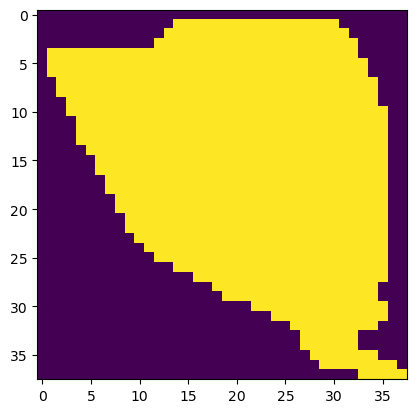

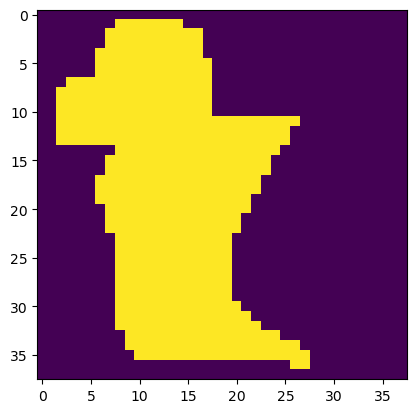

[0.49380404 0.16632101 2.        ] [0.657846   0.06190517 2.        ]


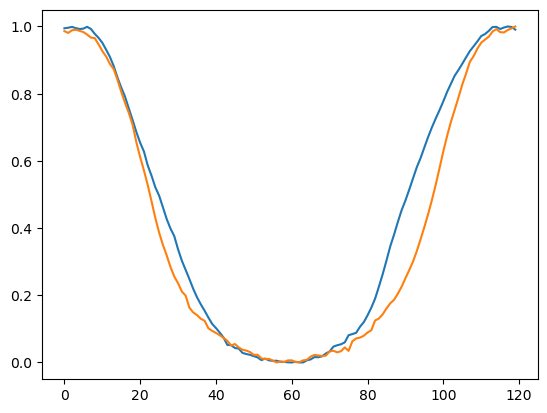

[ 0.49380404  0.16632101 10.        ] [ 0.657846    0.06190517 10.        ]


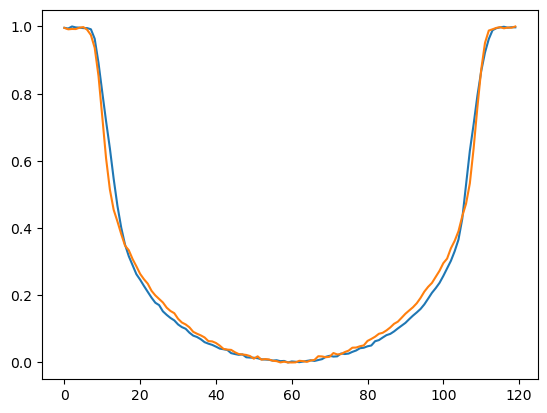

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import shape_utils,gen_ldc_ratio_grid,genlc_with_grid
file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/OM_Demo/1.npy"
sh = np.load(file)

plt.imshow(sh[0])
plt.savefig("../demo_figs/img1.png")
plt.show()

plt.imshow(sh[9])
plt.savefig("../demo_figs/img2.png")
plt.show()

file2="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_2_2/1LC_hscaled_processed.npy"
lc2 = np.load(file2)
meta2 = np.load("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_2_2/1_meta.npy")
print(meta2[0],meta2[9])
plt.plot(lc2[0,:])
plt.plot(lc2[9,:])
plt.savefig("../demo_figs/lc_rsrp2_img1_img2.png")
plt.show()

file10="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_10_10/1LC_hscaled_processed.npy"
lc10 = np.load(file10)
meta10=np.load("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_10_10/1_meta.npy")
print(meta10[0],meta10[9])
plt.plot(lc10[0,:])
plt.plot(lc10[9,:])
plt.savefig("../demo_figs/lc_rsrp10_img1_img2.png")
plt.show()



base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
Number of valid values in Kepler KOI for LDC and Rp/Rs 2745
Number of planets with SNR >= 50 is 711
Number of valid values in Kepler KOI for LDC and Rp/Rs 711


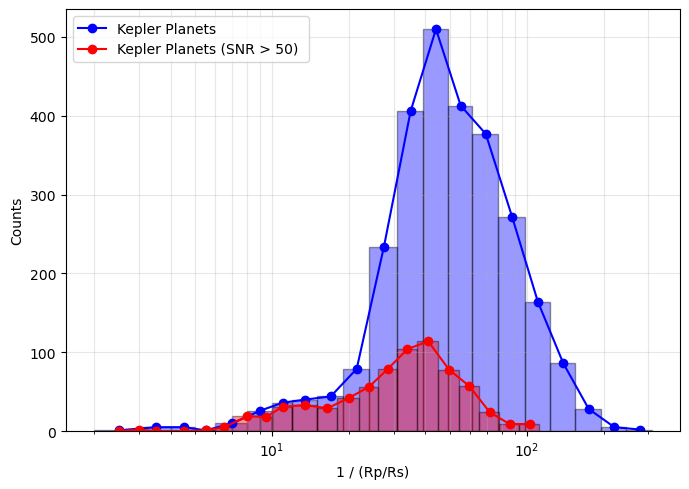

Rs/Rp bins are [[  2   3]
 [  3   3]
 [  3   4]
 [  4   5]
 [  5   6]
 [  6   7]
 [  7   9]
 [  9  10]
 [ 10  12]
 [ 12  15]
 [ 15  18]
 [ 18  22]
 [ 22  26]
 [ 26  31]
 [ 31  37]
 [ 37  45]
 [ 45  54]
 [ 54  65]
 [ 65  78]
 [ 78  93]
 [ 93 112]]
Number of targets in each bin [  0   2   0   0   1   5  19  18  31  33  29  42  56  79 104 114  78  57
  24   9   9]
   Kepler Rs/Rp Bins  No. of targets                SNR Ranges
0       [37.0, 45.0]           114.0       [50.0, 346.9, 70.0]
1       [31.0, 37.0]           104.0       [50.6, 473.2, 71.0]
2       [26.0, 31.0]            79.0       [50.8, 485.5, 81.0]
3       [45.0, 54.0]            78.0       [50.0, 194.9, 74.0]
4       [54.0, 65.0]            57.0       [50.1, 289.6, 68.0]
5       [22.0, 26.0]            56.0      [50.8, 526.1, 116.0]
6       [18.0, 22.0]            42.0      [51.4, 456.8, 170.0]
7       [12.0, 15.0]            33.0     [50.5, 5945.9, 345.0]
8       [10.0, 12.0]            31.0     [80.8, 3003.8, 633.0]
9     

In [14]:
from pathlib import Path
from utils import *
from utils import extract_key
import ast
import shutil
class SaveKeplerToRsRpBins():    
    def __init__(self,lcs_dir,snr_cut = 50, n_rsrp_bins=21):
        import kepler_distribution_utils
        self.filesfolder = Path(lcs_dir)
        self.snr_cut = snr_cut
        self.n_rsrp_bins = n_rsrp_bins
        self.obj = MLPreProcessing()
        table_subset_new = kepler_distribution_utils.main(snr_cut = self.snr_cut, n_rsrp_bins=self.n_rsrp_bins)
        self.df = table_subset_new

    def get_rsrp_bin_of_a_kepler_target(self,planet_name=None):
        matches = self.df.loc[self.df['kepname'] == planet_name, 'invrprs_bin_edges']
        objs_found_str = None
        if not matches.empty:
            objs_found_str = True
            rsrp_bin = matches.iloc[0]
            #print('rsrp_bin',rsrp_bin)
            rsrp_bin = ast.literal_eval(rsrp_bin)
            rsrp1, rsrp2 = rsrp_bin
            #print('rsrp1, rsrp2',int(rsrp1), int(rsrp2),type(rsrp1))

            kepler_binned_dir = Path(Base_Dir) / f"Kepler_RsRp_Bins/RsRp_{rsrp1}_{rsrp2}"                                
        else:
            #print("No matching kepname found")
            #objs_not_found.append(planet_name)
            objs_found_str = False
            kepler_binned_dir = None

        return kepler_binned_dir, objs_found_str
        
         
    # def distribute_kepler_into_rsrp_bins(self):
    #     ltcrv_npz_files = list(self.filesfolder.glob("*_binned.npz"))
    #     objs_not_found = []
    #     objs_found = []
    #     for i, f in enumerate(ltcrv_npz_files):
    #         #print('file',f)
    #         key = extract_key(f,split_str="_binned.npz")
    #         planet_name = key[14:]
    #         planet_name = 'K'+planet_name[1:6]+'-'+planet_name[7:]
    #         #planet_name= 'Kepler_809b'

    #         matches = self.df.loc[self.df['kepname'] == planet_name, 'invrprs_bin_edges']
    #         if not matches.empty:
    #             objs_found.append(planet_name)
    #             rsrp_bin = matches.iloc[0]
    #             #print('rsrp_bin',rsrp_bin)
    #             rsrp_bin = ast.literal_eval(rsrp_bin)
    #             rsrp1, rsrp2 = rsrp_bin
    #             #print('rsrp1, rsrp2',int(rsrp1), int(rsrp2),type(rsrp1))

    #             # copy phase folded files to Binned directory as per their rsrp ratio
    #             kepler_binned_dir = Path(Base_Dir) / f"Kepler_RsRp_Bins/RsRp_{rsrp1}_{rsrp2}"
    #             kepler_binned_dir.mkdir(parents=True, exist_ok=True)
    #             src = Path(f)
    #             shutil.copy2(src, kepler_binned_dir / src.name)
                                
    #         else:
    #             #print("No matching kepname found")
    #             objs_not_found.append(planet_name)
    #     print('Kepler objs_not_found and not Binned in RsRp',len(objs_not_found))
    #     print('Kepler objs_found and binned in RsRp',len(objs_found))
            
    #     return 
    def distribute_kepler_into_rsrp_bins(self):
        ltcrv_npz_files = list(self.filesfolder.glob("*_binned.npz"))
        objs_not_found = []
        objs_found = []
        for i, f in enumerate(ltcrv_npz_files):
            #print('file',f)
            key = extract_key(f,split_str="_binned.npz")
            planet_name = key[14:]
            planet_name = 'K'+planet_name[1:6]+'-'+planet_name[7:]
            #planet_name= 'Kepler_809b'
            kepler_binned_dir, objs_found_str = self.get_rsrp_bin_of_a_kepler_target(planet_name=planet_name)
            #matches = self.df.loc[self.df['kepname'] == planet_name, 'invrprs_bin_edges']
            if objs_found_str is True:
                objs_found.append(planet_name)  
                kepler_binned_dir.mkdir(parents=True, exist_ok=True)
                src = Path(f)
                shutil.copy2(src, kepler_binned_dir / src.name)
            
            else:
                #print("No matching kepname found")
                objs_not_found.append(planet_name)
        print('Kepler objs_not_found and not Binned in RsRp',len(objs_not_found))
        print('Kepler objs_found and binned in RsRp',len(objs_found))
            
        return 

#from class_modules import SaveKeplerToRsRpBins
from paths import *
if __name__ == "__main__":
    #kepler_distribution_utils.main(snr_cut = 50, n_rsrp_bins=21)
    lcs_dir = Home+'Kepler_Binned_LCS/'
    
    kepobj = SaveKeplerToRsRpBins(lcs_dir, snr_cut = 50, n_rsrp_bins=21)
    kepobj.distribute_kepler_into_rsrp_bins()

base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
Number of valid values in Kepler KOI for LDC and Rp/Rs 2745
Number of planets with SNR >= 50 is 711
Number of valid values in Kepler KOI for LDC and Rp/Rs 711


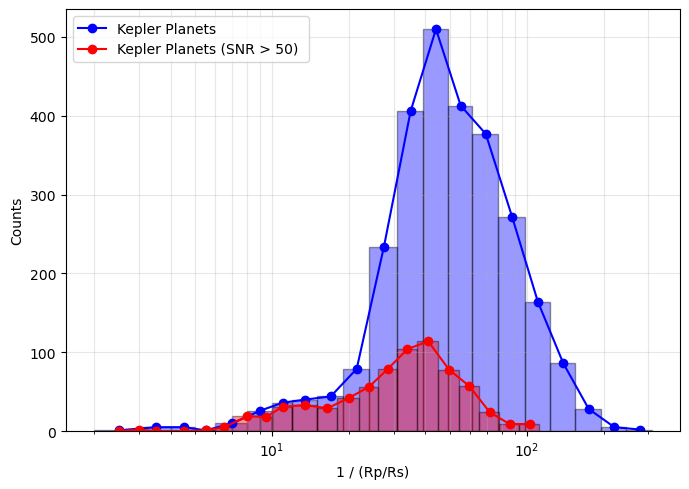

Rs/Rp bins are [[  2   3]
 [  3   3]
 [  3   4]
 [  4   5]
 [  5   6]
 [  6   7]
 [  7   9]
 [  9  10]
 [ 10  12]
 [ 12  15]
 [ 15  18]
 [ 18  22]
 [ 22  26]
 [ 26  31]
 [ 31  37]
 [ 37  45]
 [ 45  54]
 [ 54  65]
 [ 65  78]
 [ 78  93]
 [ 93 112]]
Number of targets in each bin [  0   2   0   0   1   5  19  18  31  33  29  42  56  79 104 114  78  57
  24   9   9]
   Kepler Rs/Rp Bins  No. of targets                SNR Ranges
0       [37.0, 45.0]           114.0       [50.0, 346.9, 70.0]
1       [31.0, 37.0]           104.0       [50.6, 473.2, 71.0]
2       [26.0, 31.0]            79.0       [50.8, 485.5, 81.0]
3       [45.0, 54.0]            78.0       [50.0, 194.9, 74.0]
4       [54.0, 65.0]            57.0       [50.1, 289.6, 68.0]
5       [22.0, 26.0]            56.0      [50.8, 526.1, 116.0]
6       [18.0, 22.0]            42.0      [51.4, 456.8, 170.0]
7       [12.0, 15.0]            33.0     [50.5, 5945.9, 345.0]
8       [10.0, 12.0]            31.0     [80.8, 3003.8, 633.0]
9     

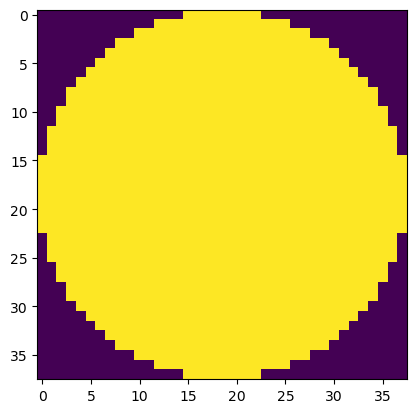

/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:168: RuntimeWarning: invalid value encountered in scalar power
  amR = (1. - am)**0.25
/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:169: RuntimeWarning: invalid value encountered in scalar power
  bmR = (1. - bm)**0.25


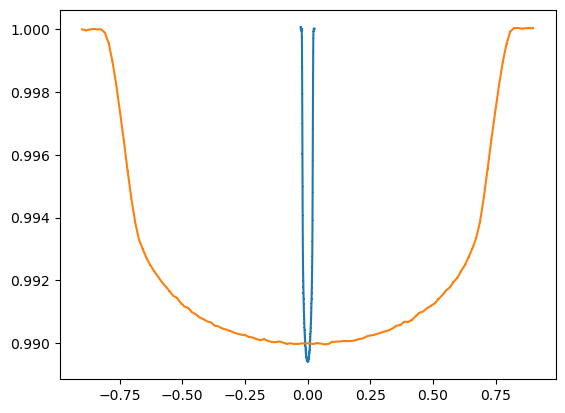

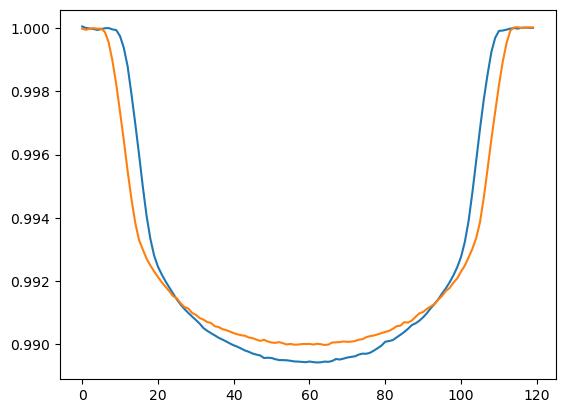

In [50]:
from megaplots_partII import *

import numpy as np
import matplotlib.pyplot as plt
from lightkurve import LightCurve
from class_modules import MLPreProcessing
from paths import Home
from koi_table import KoiTableObjs as koitab
#from genlc_with_grid import simulate_one_lc
import genlc_with_grid
import shape_utils
import add_noise_to_lcs_files,processing_transit_region
class GenPlots_MegaPartII():
        def __init__(self, rsrp1=10,rsrp2=12, snr=1000, kepobj_file = None):
            """
            kepobj_file = None/"kplr007382313_kepler_1220b_binned.npz"
            """
            
            self.kepobj_file = kepobj_file
            self.rsrp1 = rsrp1
            self.rsrp2 = rsrp2
            self.snr = snr

            self.mlprep = MLPreProcessing()
            self.savekep = SaveKeplerToRsRpBins(lcs_dir, snr_cut = 50, n_rsrp_bins=21)
            
            
            pass

        def get_a_kepler_target(self):
            koi = koitab(files_dir = Kepler_Dir,koi_file_name = KOI_Table_Filename,verbose=False)
            koi_table = koi.koi_table
            #print(koi_table)
            koi.get_koi_confirmed()
            koi_conf_plans_tabl = koi.koi_conf_plans_tab
            plans_table = koi_conf_plans_tabl
            plans_table_sel = plans_table[(plans_table['koi_model_snr'] >= self.snr) &
                                (plans_table['koi_ror'] > 1/self.rsrp2) &
                                (plans_table['koi_ror'] < 1/self.rsrp1)]
            plans_table_sel2 = plans_table_sel[plans_table_sel['koi_model_snr']==np.max(plans_table_sel['koi_model_snr'])]
            print('plans_table_sel2',plans_table_sel2['koi_model_snr'])
            self.kepobj = plans_table_sel2['kepname'].to_numpy()[0]
            self.kepid_str = plans_table_sel2['kepid_str'].to_numpy()[0]
            self.keobj_ror = plans_table_sel2['koi_ror'].to_numpy()[0]
            self.kepobj_ldca = plans_table_sel2['koi_ldm_coeff1'].to_numpy()[0]
            self.kepobj_ldcb = plans_table_sel2['koi_ldm_coeff2'].to_numpy()[0]
                
            kep_filename = self.kepid_str + '_'+ 'k' + self.kepobj[1:6] + '_' + self.kepobj[7:]+'_binned_transit_interp.npz'
            print(koi_conf_plans_tabl.columns,plans_table_sel2['kepid_str'])
            print('kep_filename',kep_filename,self.kepobj[0])
            if self.kepobj_file is None:
                self.kepobj_file = kep_filename
            kepler_binned_dir, objs_found_str = self.savekep.get_rsrp_bin_of_a_kepler_target(planet_name=self.kepobj)
            self.kepobj_path = kepler_binned_dir / self.kepobj_file
 
            
        def overlays_lcs_circle(self,seed=50):
            
            data = np.load(self.kepobj_path)
            lc_fold_load = LightCurve(time=data['time'], flux=data['flux'], flux_err=data['flux_err'])
            x = lc_fold_load.time.value
            y = lc_fold_load.flux.value
            yerr = lc_fold_load.flux_err.value

            # generate eightbit lc with same LDC and radius ratio
            shape_circle = shape_utils.generate_circles(num_maps=1, size=shape_utils.SHAPE_SIZE)[0]
            plt.imshow(shape_circle)
            plt.show()

            self.rsrp = round(1/self.keobj_ror)
            time,flux = genlc_with_grid.simulate_one_lc(shape_circle, v=0.4, t_ref=0.0, LDlaw='quadratic', LDCs=[self.kepobj_ldca, self.kepobj_ldcb],
                    star2mega_radius_ratio=self.rsrp , n_times=2000)
            flux_error = yerr
            
            tar_l = 200
            L = len(yerr)
            start_pad = (tar_l - L) // 2
            
            padded_flux = genlc_with_grid.extract_and_interpolate(flux, target_length=tar_l)
            padded_err = np.zeros(tar_l)
            
            padded_err[start_pad:start_pad + L] = yerr[:L]
            padded_err[0:start_pad] = yerr[0:start_pad]
            padded_err[start_pad + L:] = yerr[-start_pad:]
            
            
            rng = np.random.default_rng(seed)
            noise = rng.standard_normal(len(padded_flux))
            noise_multigauss= noise*padded_err
            lcs_noisy = padded_flux + noise_multigauss
            
            
            time_gen_ext = np.linspace(-1, 1, len(padded_flux) + 40)
            #flux_error = np.zeros(len(padded_flux)+40, dtype=np.float32)
            
            train_lcs_ext = np.concatenate((np.ones(20) + noise_multigauss[0:20],
                                            lcs_noisy,np.ones(20) + noise_multigauss[-20:] ))
    
            flux_err_ext = np.concatenate((
               padded_err[0:20],
               padded_err,
               padded_err[-40:-20]
            ))


            # LDC and radius ratio directory
            self.lc_dir = Path(Base_Dir) / "Data_For_Plots"
            self.lc_dir.mkdir(parents=True, exist_ok=True)
            self.lc_dir_filename = self.lc_dir / f"circle_rsrp{self.rsrp}_binned.npz"

            
            np.savez_compressed(
                self.lc_dir_filename,
                time=time_gen_ext,
                flux=train_lcs_ext,
                flux_err=flux_err_ext
            )
        
            
            trs = processing_transit_region.TransitRegionSelector()
            trs.process_one_target(self.lc_dir_filename, target_ltcrv_length=120)

            
            data_circ = np.load(self.lc_dir / f"circle_rsrp{self.rsrp}_binned_transit_interp.npz")
            lc_fold_load = LightCurve(time=data_circ['time'], flux=data_circ['flux'], flux_err=data_circ['flux_err'])
            x_circ = lc_fold_load.time.value
            y_circ = lc_fold_load.flux.value
            yerr_circ = lc_fold_load.flux_err.value
            
            plt.errorbar(x, y, yerr=yerr, xerr=None, fmt='',label='Kepler')
            plt.errorbar(x_circ, y_circ, yerr=yerr_circ, xerr=None, fmt='',label='circle')
            plt.legend()
            plt.show()

            plt.plot(y)
            plt.plot(y_circ)
            
            plt.show()

            #========
            tar_l = 90
            L = len(yerr)
            start_pad = (tar_l - L) // 2

            transit_flux = genlc_with_grid.extract_and_interpolate(flux, target_length=tar_l)
            padded_flux = np.ones(tar_l+30)
            padded_err = np.zeros(tar_l)
            
            padded_err[start_pad:start_pad + L] = yerr[:L]
            padded_err[0:start_pad] = yerr[0:start_pad]
            padded_err[start_pad + L:] = yerr[-start_pad:]
            
            
            rng = np.random.default_rng(seed)
            noise = rng.standard_normal(len(padded_flux))
            noise_multigauss= noise*padded_err
            lcs_noisy = padded_flux + noise_multigauss
            
            
            time_gen_ext = np.linspace(-1, 1, len(padded_flux) + 40)
            #flux_error = np.zeros(len(padded_flux)+40, dtype=np.float32)
            
            train_lcs_ext = np.concatenate((np.ones(20) + noise_multigauss[0:20],
                                            lcs_noisy,np.ones(20) + noise_multigauss[-20:] ))
    
            flux_err_ext = np.concatenate((
               padded_err[0:20],
               padded_err,
               padded_err[-40:-20]
            ))


            # LDC and radius ratio directory
            self.lc_dir = Path(Base_Dir) / "Data_For_Plots"
            self.lc_dir.mkdir(parents=True, exist_ok=True)
            self.lc_dir_filename = self.lc_dir / f"circle_rsrp{self.rsrp}_binned.npz"

            
            np.savez_compressed(
                self.lc_dir_filename,
                time=time_gen_ext,
                flux=train_lcs_ext,
                flux_err=flux_err_ext
            )
        
            
            trs = processing_transit_region.TransitRegionSelector()
            trs.process_one_target(self.lc_dir_filename, target_ltcrv_length=120)

            
            data_circ = np.load(self.lc_dir / f"circle_rsrp{self.rsrp}_binned_transit_interp.npz")
            lc_fold_load = LightCurve(time=data_circ['time'], flux=data_circ['flux'], flux_err=data_circ['flux_err'])
            x_circ = lc_fold_load.time.value
            y_circ = lc_fold_load.flux.value
            yerr_circ = lc_fold_load.flux_err.value
            
            plt.errorbar(x, y, yerr=yerr, xerr=None, fmt='',label='Kepler')
            plt.errorbar(x_circ, y_circ, yerr=yerr_circ, xerr=None, fmt='',label='circle')
            plt.legend()
            plt.show()

            plt.plot(y)
            plt.plot(y_circ)
            
            plt.show()


            


obj = GenPlots_MegaPartII(rsrp1=10,rsrp2=12)
obj.get_a_kepler_target()
obj.overlays_lcs_circle()

In [ ]:
def plot_kepler_prediction(lc_filename,out_filename,idx_sel = np.array([1,5,7]),num = 3 ):

                                                               lc_filename = f'Kepler/kepler_folded_lcs_few_smooth_processed.npy'
out_filename = f"Kepler/kepler_folded_lcs_few_smooth_processed_PredctdShape.npy"
parameters_objs = np.load("Kepler/kepler_folded_lcs_few_parameters_info.npy", allow_pickle=False)

nspred_Kepler = np.load(out_filename)
nsTest_kepler_lcs = np.load(lc_filename)

# kepnames_sel = np.array( ['Kepler-730b', 'Kepler-706b', 'Kepler-43b', 'Kepler-71b', 'Kepler-412b','Kepler-77b', 'Kepler-423b', 'Kepler-1b'])
idx_sel = np.array([1,5,7])
num = 3
phase = np.linspace(-1.0,1.0,len(nsTest_kepler_lcs[0]))

fontsize = 14
alpha_grid = 0.5
cbar_ticks = [0.0,0.2, 0.4, 0.6, 0.8, 1.0]

fig,ax=plt.subplots(num,2,figsize=(7,7),gridspec_kw={'width_ratios': [2.5,1.5], 'wspace': -0.09, 'hspace': 0.3})

k = 0
for i in np.arange(0, num):
    idx = idx_sel[k+i]
    ax[i][1].tick_params(left=False,right=False,labelleft=False,labelbottom=False,bottom=False,)
    #if(i<num-1): ax[i][0].tick_params(labelbottom = False, bottom = False)
    img = ax[i][1].imshow(nspred_Kepler[idx,:,:], cmap='inferno')
    cbar = plt.colorbar(img, ax= ax[i][1])
    cbar.set_ticks(cbar_ticks)
    cbar.set_ticklabels(cbar_ticks)
    cbar.ax.tick_params(labelsize=fontsize)
    ax[i][0].set_ylabel('Flux', size=fontsize)
    ax[i][0].plot(phase,nsTest_kepler_lcs[idx],".-", color = 'tab:red', linewidth='1',label="",markersize=2)
    #ax[i][0].set_title(f"{KIC_ids_sel[idx]} ({kepnames[idx]})\n $R_p/R_s$: {rp_rs_ratio[idx]:.2f}; $SNR$: {snr[idx]:.2f}",fontsize= fontsize)
    ax[i][0].set_title(f"{parameters_objs['kicid'][idx]} ({parameters_objs['kepname'][idx]})",fontsize= fontsize)

    ax[i][0].grid('on',linestyle='--', linewidth=0.5, color='gray',alpha=alpha_grid)
    ax[i][0].tick_params(labelsize=fontsize)

        # --- Put Y ticks on right side ---
    ax[i][0].yaxis.tick_left()
    ax[i][0].yaxis.set_label_position("left")
    ax[i][0].set_yticks([0.0,0.25,0.50,0.75, 1.0])
    ax[i][0].set_yticklabels(['0.00','0.25','0.50','0.75', '1.00'],fontsize=fontsize-1)
    ax[i][0].text(
    0.25, 0.8, f"$R_p/R_s$: {parameters_objs['rprs'][idx]:.2f} , $SNR$: {parameters_objs['snr'][idx]:.0f}",
    transform=ax[i][0].transAxes,fontsize= fontsize-3,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.0))


    major_xticks = [-1.0,-0.5, 0, 0.5,1.0]
    #major_xticklabels = ["-1", "0", "1"]
    major_xticklabels = ["-1.0", "-0.5", "0","0.5", "1.0"]
    ax[i][0].set_xticks(major_xticks)

    # -------------------------------
    # Only last row shows X tick labels
    # -------------------------------
    if i == len(idx_sel) - 1:
        ax[i][0].set_xticklabels(major_xticklabels,fontsize=fontsize)
    else:
        ax[i][0].set_xticklabels([])  # hide labels on other rows
    
    # --- Minor ticks ---
    from matplotlib.ticker import AutoMinorLocator
    ax[i][0].minorticks_on()
    ax[i][0].xaxis.set_minor_locator(AutoMinorLocator(2))
    ax[i][0].yaxis.set_minor_locator(AutoMinorLocator(2))
    
    # --- Tick style: ALL ticks go INSIDE the axes ---
    ax[i][0].tick_params(axis='both', which='major', direction='in', length=5)
    ax[i][0].tick_params(axis='both', which='minor', direction='in', length=3)
ax[2][0].set_xlabel('Phase (Arbitrary Unit)', size=fontsize)
plt.savefig(
    'figures/kepler_selected_predictions.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.2
)
plt.show()

In [1]:
from kepler_distribution_utils import *
from class_modules import MLPreProcessing

from utils import extract_key
import ast
from pathlib import Path
import shutil
from paths import *

class SaveKeplerToRsRpBins():
    def __init__(self,lcs_dir,snr_cut = 50, n_rsrp_bins=21):
        self.filesfolder = Path(lcs_dir)
        self.snr_cut = snr_cut
        self.n_rsrp_bins = n_rsrp_bins
        self.obj = MLPreProcessing()
        table_subset_new = main(snr_cut = self.snr_cut, n_rsrp_bins=self.n_rsrp_bins)
        self.df = table_subset_new
        
        
    def distribute_kepler_into_rsrp_bins(self):
        ltcrv_npz_files = list(self.filesfolder.glob("*_binned.npz"))
        objs_not_found = []
        objs_found = []
        for i, f in enumerate(ltcrv_npz_files):
            #print('file',f)
            key = extract_key(f,split_str="_binned.npz")
            planet_name = key[14:]
            planet_name = 'K'+planet_name[1:6]+'-'+planet_name[7:]
            #planet_name= 'Kepler_809b'

            matches = self.df.loc[self.df['kepname'] == planet_name, 'invrprs_bin_edges']
            if not matches.empty:
                objs_found.append(planet_name)
                rsrp_bin = matches.iloc[0]
                #print('rsrp_bin',rsrp_bin)
                rsrp_bin = ast.literal_eval(rsrp_bin)
                rsrp1, rsrp2 = rsrp_bin
                #print('rsrp1, rsrp2',int(rsrp1), int(rsrp2),type(rsrp1))

                # copy phase folded files to Binned directory as per their rsrp ratio
                kepler_binned_dir = Path(Base_Dir) / f"Kepler_RsRp_Bins/RsRp_{rsrp1}_{rsrp2}"
                kepler_binned_dir.mkdir(parents=True, exist_ok=True)
                src = Path(f)
                shutil.copy2(src, kepler_binned_dir / src.name)
                                
            else:
                #print("No matching kepname found")
                objs_not_found.append(planet_name)
        print('Kepler objs_not_found and not Binned in RsRp',len(objs_not_found))
        print('Kepler objs_found and binned in RsRp',len(objs_found))
            
        return 
        
lcs_dir = '/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/kepler_data/phase_folded_lcs/Binned_LC/'
lcs_dir = Home+'Kepler_Binned_LCS/'
kepobj = SaveKeplerToRsRpBins(lcs_dir)

kepobj.distribute_kepler_into_rsrp_bins()

ImportError: cannot import name 'main' from partially initialized module 'kepler_distribution_utils' (most likely due to a circular import) (/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/clean_codes_v2/kepler_distribution_utils.py)

In [2]:
rprs = np.array([1/112.12019285, 0.25, 0.4])

inv_rprs = np.round(1.0 / rprs).astype(int)

print(inv_rprs)

[112   4   2]


In [29]:
import numpy as np
import sys
from class_modules import MLPreProcessing, MLInference
import train_on_kepler_noise
from paths import Config_Dir, Infer_LC_Dir
import argparse,json
from rich import print as prcolor

import numpy as np
import matplotlib.pyplot as plt
import subprocess
import shape_utils,gen_ldc_ratio_grid,genlc_with_grid
import add_noise_to_lcs_files,processing_transit_region
import preproclc_hscaled,dataset_split
from pathlib import Path
from paths import *
from models import *
import os
from binary_classifier import *
from rich import print as prcolor
import re

model_dir =f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Model/RsRp_7_9/"
n_scale = 2
model = model_dir + f"model_n{n_scale}_checkpoint.pth"

checkpoint = torch.load(model, map_location='cpu')
print(checkpoint.keys())

generator = HybridConvNet(n=n_scale)

generator.load_state_dict(checkpoint['model_state_dict'])

print("Last epoch:", checkpoint['epoch'])

print("Best validation loss:", checkpoint['best_val_loss'])
print("Validation loss counter:", checkpoint['val_loss_counter'])

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_val_loss', 'val_loss_counter'])
Last epoch: 299


/tmp/ipykernel_1654924/3007130132.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model, map_location='cpu')


In [21]:
from pathlib import Path
import numpy as np
import re
st = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/figures/"
pt = Path(st)
dygnostic_dir = pt / "dygnostics"

dygnostic_dir.mkdir(parents=True, exist_ok=True)


sh = np.load("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/OM_Demo/1.npy")
lc = np.load("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_2_3/1LC.npy")
lc_sc = np.load("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_2_3/1LC_hscaled.npy")
lc_sc_pr = np.load("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_2_3/1LC_hscaled_processed.npy")

print("sh.shape,lc.shape",sh.shape,lc.shape)
print("lc_sc.shape,lc_sc_pr.shape",lc_sc.shape,lc_sc_pr.shape)


noisy_ltcrv_folder="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/LC_Demo/proc/RsRp_2_3/Binned_LC"
N = 1
Num = 21+5
#print(list(Path(noisy_ltcrv_folder).glob(f"{N}LC{Num}*.npz")))


files = sorted(
    [
        f for f in Path(noisy_ltcrv_folder).glob(f"{N}LC*.npz")
        if (m := re.search(rf"{N}LC(\d+)", f.stem)) and int(m.group(1)) >= Num
    ],
    key=lambda f: int(re.search(rf"{N}LC(\d+)", f.stem).group(1))
)

print('files ',files, len(files) )

sh.shape,lc.shape (12, 38, 38) (12, 120)
lc_sc.shape,lc_sc_pr.shape (12, 120) (12, 120)
files  [] 0


In [ ]:
import csv
import json
import subprocess

ROW_NUM = 0   # choose row index

csv_file = "params.csv"
json_file = "config.json"

# Read selected row
with open(csv_file, newline="") as f:
    reader = csv.reader(f)
    next(reader)  # skip header

    rows = list(reader)
    row = rows[ROW_NUM]

rsrp1 = row[0]
rsrp2 = row[2]

# Load json
with open(json_file) as f:
    config = json.load(f)

# Update keys
config["rsrp1"] = rsrp1
config["rsrp2"] = rsrp2

# Save updated json
with open(json_file, "w") as f:
    json.dump(config, f, indent=4)

# Run scripts with command-line arguments
subprocess.run([
    "python",
    "script1.py",
    str(rsrp1),
    str(rsrp2)
])

subprocess.run([
    "python",
    "script2.py",
    str(rsrp1),
    str(rsrp2)
])

In [17]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
maps_dir = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Raw_LC/"
#list(self.filesfolder.glob("*_binned.npz"))
ltcrv_npz_files = list(Path(maps_dir).glob("*_binned_transit_interp.npz"))
ltcrv_npz_files=sorted(ltcrv_npz_files)
print(ltcrv_npz_files[1])
len_lc = np.load(ltcrv_npz_files[0])
flux = len_lc['flux'].shape[0]
print(len_lc,flux )


/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Raw_LC/kplr008359498_kepler_77b_binned_transit_interp.npz
NpzFile '/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Raw_LC/kplr006522242_kepler_706b_binned_transit_interp.npz' with keys: time, flux, flux_err 120


min_rsrp,max_rsrp 10.0 100.0
[ 11.   12.   13.7  15.6  18.   21.4  27.3  35.6  52.6 100. ]


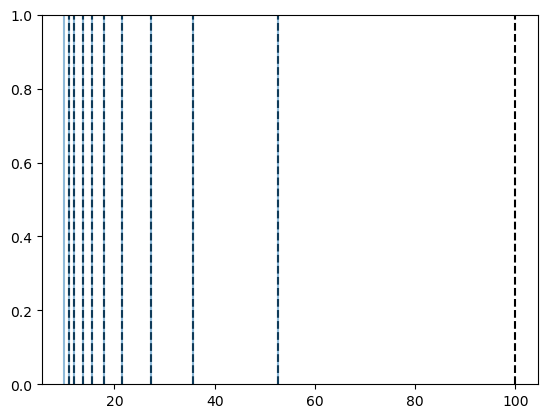

In [8]:
import numpy as np
import matplotlib.pyplot as plt
rprs = np.linspace(1/100,1/10,50)
rsrp = np.round(1.0/rprs,0)
min_rsrp = np.min(rsrp)
max_rsrp = np.max(rsrp)
print('min_rsrp,max_rsrp',min_rsrp,max_rsrp)
# rsrp
rsrp_nbins = 10
percentiles = np.zeros(rsrp_nbins)
for p in range(rsrp_nbins):
    percentiles[p] = np.percentile(rsrp,(100/len(percentiles))*(p+1))
print(percentiles)   
bins_edge_low = np.zeros(rsrp_nbins)
bins_edge_low[0] = min_rsrp
bins_edge_low[1:] = percentiles[0:9]

bins_edge_hig = np.zeros(rsrp_nbins)
bins_edge_hig =percentiles
#bins_edge_hig[1:] = percentiles[0:9]

for i in range(rsrp_nbins):
    plt.axvline(bins_edge_low[i],alpha=0.5)
    plt.axvline(bins_edge_hig[i], ls='--',color='k',)
plt.show()

2745


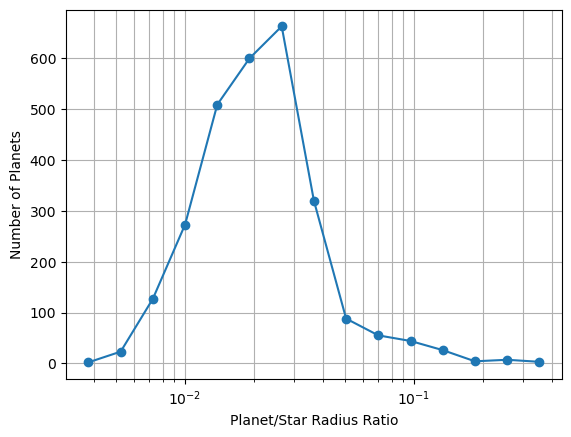

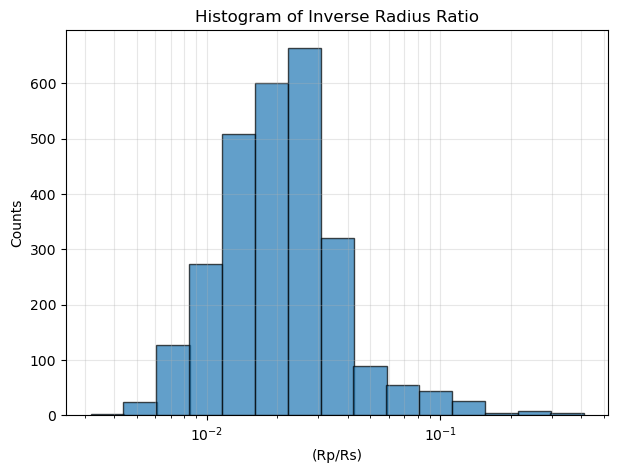

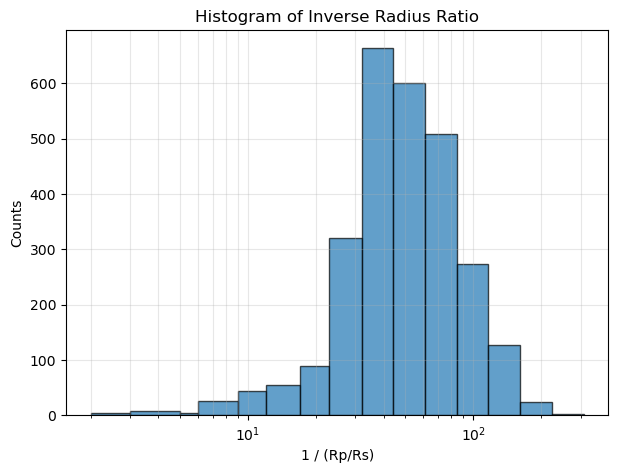

711


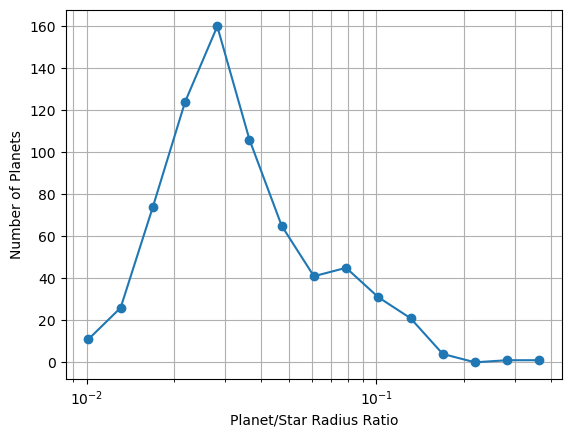

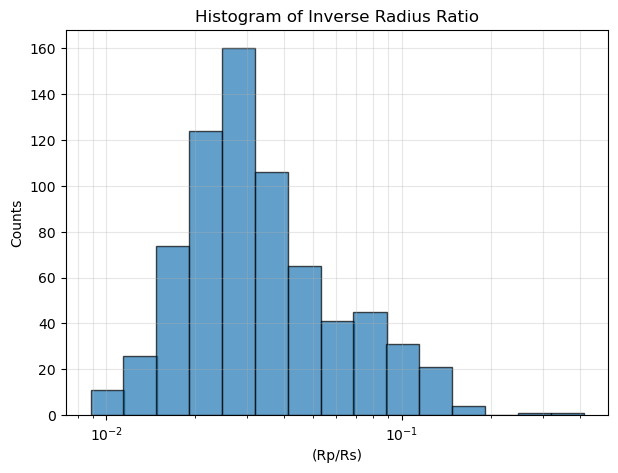

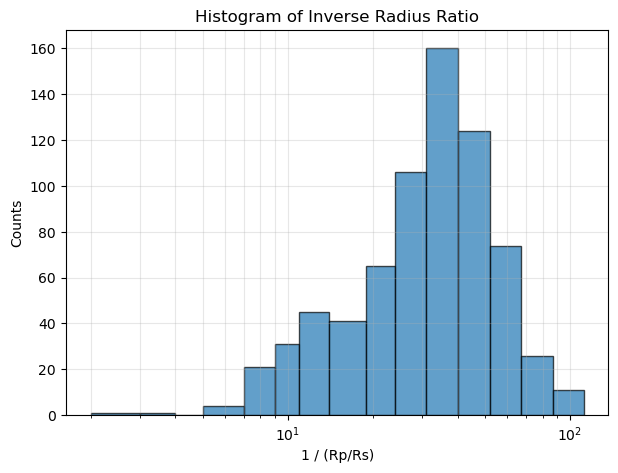

(array([[  2,   3],
        [  3,   4],
        [  4,   5],
        [  5,   7],
        [  7,   9],
        [  9,  11],
        [ 11,  14],
        [ 14,  19],
        [ 19,  24],
        [ 24,  31],
        [ 31,  40],
        [ 40,  52],
        [ 52,  67],
        [ 67,  87],
        [ 87, 112]]),
 array([  1,   1,   0,   4,  21,  31,  45,  41,  65, 106, 160, 124,  74,
         26,  11]))

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from general_utils import *

planet_ldc_file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/kepler_ldc_coeffs_conf_planets.npy"
ldcs_coeffs = np.load(planet_ldc_file)
print(len(ldcs_coeffs[:,0]))
rprs = ldcs_coeffs[:,2]

make_log_bins_and_save(rprs, outfile="inverse_ratio_bins.txt")

planet_ldc_file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/kepler_ldc_coeffs_conf_planets_snr50.npy"
ldcs_coeffs = np.load(planet_ldc_file)
print(len(ldcs_coeffs[:,0]))
rprs = ldcs_coeffs[:,2]

make_log_bins_and_save(rprs, outfile="inverse_ratio_bins.txt")

base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
2745
711
bin_edges [0.003223   0.00436661 0.00591602 0.00801519 0.01085922 0.01471238
 0.01993277 0.0270055  0.03658784 0.04957027 0.06715925 0.09098932
 0.12327498 0.16701655 0.2262789  0.30656927 0.415349  ]
inverse_bins [2 3]
bin_edges [0.008919   0.01133893 0.01441545 0.0183267  0.02329917 0.02962078
 0.03765759 0.04787498 0.06086459 0.07737858 0.0983732  0.12506416
 0.158997   0.20213661 0.25698102 0.326706   0.415349  ]
inverse_bins [2 3]


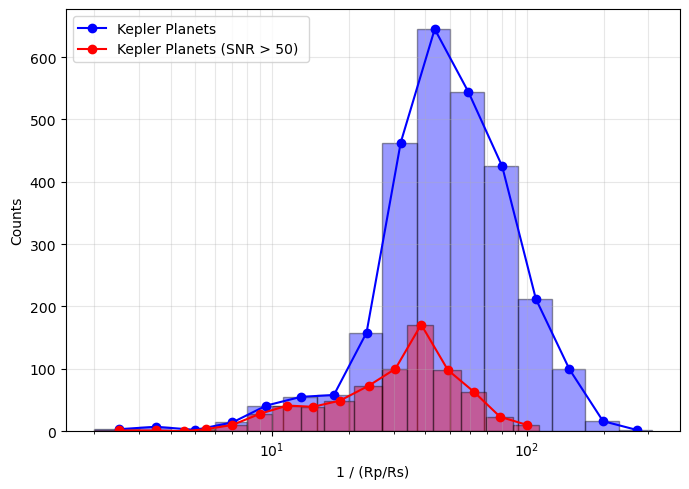

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from class_modules import MLPreProcessing, MLInference
from paths import *

class LogBinHistogram:
    """
    Create and overlay logarithmic histograms of Rp/Rs.
    """

    def __init__(self, nbins=15, figsize=(7, 5),figure_dir = None):

        self.nbins = nbins

        # # Figure for Rp/Rs
        # self.fig_ratio, self.ax_ratio = plt.subplots(figsize=figsize)

        # self.ax_ratio.set_xscale('log')
        # self.ax_ratio.set_xlabel("Rp/Rs")
        # self.ax_ratio.set_ylabel("Counts")
        # self.ax_ratio.grid(True, which='both', alpha=0.3)

        # Figure for inverse ratio
        self.fig_inv, self.ax_inv = plt.subplots(figsize=figsize)

        self.ax_inv.set_xscale('log')
        self.ax_inv.set_xlabel("1 / (Rp/Rs)")
        self.ax_inv.set_ylabel("Counts")
        self.ax_inv.grid(True, which='both', alpha=0.3)

    def add(
        self,
        ratio,
        label=None,
        alpha=0.5,
        color=None,
        outfile=None,
        show_points=True,
        show_bar=True
    ):
        """
        Add histogram to existing plots.

        Parameters
        ----------
        ratio : array-like
            Rp/Rs values.
        label : str
            Legend label.
        alpha : float
            Transparency.
        color : str
            Plot color.
        outfile : str
            Save inverse bins if provided.
        """

        ratio = np.asarray(ratio)

        rmin = np.min(ratio)
        rmax = np.max(ratio)

        # Logarithmic bins
        bin_edges = np.logspace(
            np.log10(rmin),
            np.log10(rmax),
            self.nbins + 1
        )
        print('bin_edges',bin_edges)
        # Counts
        counts, _ = np.histogram(ratio, bins=bin_edges)

        # ----- Rp/Rs plots -----

        # Geometric centers
        bin_centers = np.sqrt(
            bin_edges[:-1] * bin_edges[1:]
        )

        # Linear widths
        bin_widths = np.diff(bin_edges)

        # # Line plot
        # if show_points:

        #     self.ax_ratio.plot(
        #         bin_centers,
        #         counts,
        #         marker='o',
        #         label=label,
        #         color=color
        #     )

        # # Bar plot
        # if show_bar:

        #     self.ax_ratio.bar(
        #         bin_centers,
        #         counts,
        #         width=bin_widths,
        #         align='center',
        #         edgecolor='black',
        #         alpha=alpha,
        #         color=color
        #     )

        # ----- Inverse ratio bins -----

        inv_edges = 1.0 / bin_edges

        inverse_bins = np.zeros(
            (self.nbins, 2),
            dtype=int
        )

        for i in range(self.nbins):

            left = min(
                inv_edges[i],
                inv_edges[i + 1]
            )

            right = max(
                inv_edges[i],
                inv_edges[i + 1]
            )

            inverse_bins[i, 0] = int(round(left))
            inverse_bins[i, 1] = int(round(right))

        # Sort increasing
        order = np.argsort(inverse_bins[:, 0])

        inverse_bins = inverse_bins[order]
        counts = counts[order]

        # Save if requested
        if outfile is not None:

            np.savetxt(
                outfile,
                inverse_bins,
                fmt="%d",
                header="left_edge(1/ratio) right_edge(1/ratio)"
            )

        # Centers and widths
        inv_centers = 0.5 * (
            inverse_bins[:, 0]
            + inverse_bins[:, 1]
        )

        inv_widths = (
            inverse_bins[:, 1]
            - inverse_bins[:, 0]
        )

        # Plot inverse histogram
        if show_points:

            self.ax_inv.plot(
                inv_centers,
                counts,
                marker='o',
                label=label,
                color=color
            )
        self.ax_inv.bar(
            inv_centers,
            counts,
            width=inv_widths,
            align='center',
            edgecolor='black',
            alpha=alpha,
            color=color,
            label=''
        )
        print('inverse_bins',inverse_bins[0])
        return inverse_bins, counts

    def show(self):

        #self.ax_ratio.legend()
        self.ax_inv.legend()

        #self.fig_ratio.tight_layout()
        self.fig_inv.tight_layout()
        # if figure_dir is not None:
        #     plt.savefig(
        #     figure_dir / "kepler_rsrp_distribution.png",
        #     dpi=500,
        #     bbox_inches='tight',
        #     pad_inches=0.2
        #     )
        plt.show()

obj = MLPreProcessing()

planet_ldc_file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/kepler_ldc_coeffs_conf_planets.npy"
ldcs_coeffs = np.load(planet_ldc_file)
print(len(ldcs_coeffs[:,0]))
rp_rs_1 = ldcs_coeffs[:,2]

planet_ldc_file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/kepler_ldc_coeffs_conf_planets_snr50.npy"
ldcs_coeffs = np.load(planet_ldc_file)
print(len(ldcs_coeffs[:,0]))
rp_rs_2 = ldcs_coeffs[:,2]



hist = LogBinHistogram(nbins=16,)

inverse_bins, counts = hist.add(
    rp_rs_1,
    label="Kepler Planets",
    color='blue',
    alpha=0.4
)

hist.add(
    rp_rs_2,
    label=f"Kepler Planets (SNR > 50) ",
    color='red',
    alpha=0.4
)

hist.show()

bin_edges [0.003223   0.00406204 0.0051195  0.00645224 0.00813194 0.01024891
 0.01291698 0.01627963 0.02051767 0.02585899 0.0325908  0.04107509
 0.05176807 0.06524473 0.08222973 0.10363641 0.13061583 0.16461875
 0.20747356 0.26148467 0.32955636 0.415349  ]
inverse_bins [2 3]
bin_edges [0.008919   0.01070901 0.01285827 0.01543888 0.0185374  0.02225779
 0.02672485 0.03208843 0.03852846 0.04626099 0.0555454  0.06669315
 0.08007823 0.09614964 0.11544652 0.13861621 0.16643598 0.19983907
 0.23994605 0.28810234 0.34592343 0.415349  ]
inverse_bins [2 3]


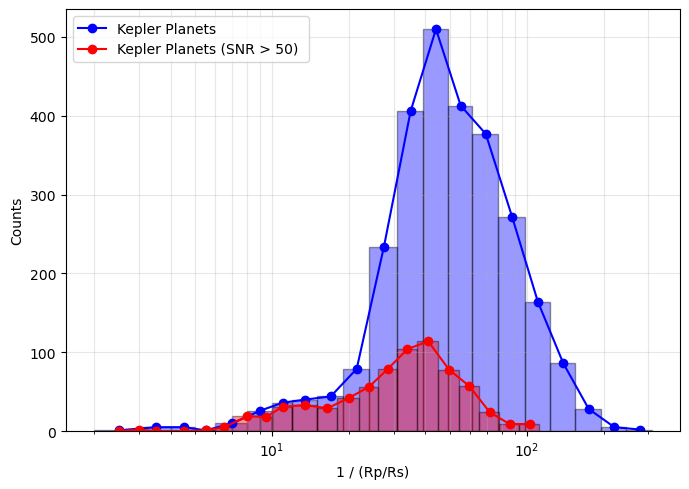

test [ 37.  45. 114.]


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err,kepid_str,kepname,invrprs_bin_index,invrprs_bin_edges,rprs_bin_edges
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.130,-0.080,0.100,0.080,0.100,kplr010872983,Kepler-228d,2,"(26, 31)","(0.03225806451612903, 0.038461538461538464)"
9,10,10910878,K00757.01,Kepler-229 c,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.075,0.030,0.082,0.031,0.081,kplr010910878,Kepler-229c,9,"(15, 18)","(0.05555555555555555, 0.06666666666666667)"
10,11,11446443,K00001.01,Kepler-1 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0.811,0,...,0.069,-0.270,0.170,0.270,0.170,kplr011446443,Kepler-1b,11,"(7, 9)","(0.1111111111111111, 0.14285714285714285)"
11,12,10666592,K00002.01,Kepler-2 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.690,-3.670,0.510,4.190,0.750,kplr010666592,Kepler-2b,7,"(12, 15)","(0.06666666666666667, 0.08333333333333333)"
12,13,6922244,K00010.01,Kepler-8 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0.998,0,...,0.067,0.176,0.068,0.178,0.068,kplr006922244,Kepler-8b,8,"(10, 12)","(0.08333333333333333, 0.1)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6010,6011,4570949,K01658.01,Kepler-76 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.067,-0.033,0.068,0.033,0.068,kplr004570949,Kepler-76b,8,"(10, 12)","(0.08333333333333333, 0.1)"
6044,6045,10005758,K01783.02,Kepler-1662 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.991,0,...,0.170,-0.240,0.300,0.240,0.300,kplr010005758,Kepler-1662c,5,"(22, 26)","(0.038461538461538464, 0.045454545454545456)"
6132,6133,5437945,K03791.02,Kepler-460 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.902,0,...,0.150,-0.070,0.490,0.280,0.200,kplr005437945,Kepler-460c,5,"(22, 26)","(0.038461538461538464, 0.045454545454545456)"
6165,6166,1873513,K04928.01,Kepler-1624 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0.998,0,...,0.068,-0.670,0.130,0.670,0.130,kplr001873513,Kepler-1624b,12,"(9, 10)","(0.1, 0.1111111111111111)"


In [14]:


import numpy as np
import pandas as pd


def add_inverse_bins_as_input(df, bins, column='rprs',
                              outfile='binned_table.csv'):
    """
    Bin using input bins defined in 1/rprs space.

    Parameters
    ----------
    bins : list of [left, right]
        Bin edges in inverse-rprs space (1/rprs)
    """

    df = df.copy()

    rprs = df[column].to_numpy()
    inv_rprs = 1.0 / rprs

    bins = np.asarray(bins)

    bin_idx = np.full(len(df), -1, dtype=int)

    # assign bins in inverse space
    for i, (l, r) in enumerate(bins):
        mask = (inv_rprs >= l) & (inv_rprs < r)
        bin_idx[mask] = i

    # include right edge for last bin
    l, r = bins[-1]
    bin_idx[(inv_rprs >= l) & (inv_rprs <= r)] = len(bins) - 1

    df['invrprs_bin_index'] = bin_idx

    # store inverse-space bins (as given)
    df['invrprs_bin_edges'] = [
        tuple(bins[i]) if i >= 0 else (np.nan, np.nan)
        for i in bin_idx
    ]

    # convert back to rprs-space bins
    df['rprs_bin_edges'] = [
        (1.0 / bins[i][1], 1.0 / bins[i][0])
        if i >= 0 else (np.nan, np.nan)
        for i in bin_idx
    ]

    df.to_csv(outfile, index=False)

    return df
koi_table_folder = '/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/'
koi_table_filename = "koi_cumulative_2025.06.28_01.24.15.csv"
koi = koitab(files_dir = koi_table_folder,koi_file_name = koi_table_filename,
             verbose=False)
koi_table = koi.koi_table
#print(koi_table)
koi.get_koi_confirmed()
koi_conf_plans_tabl = koi.koi_conf_plans_tab
    
df =koi_conf_plans_tabl[koi_conf_plans_tabl['koi_model_snr']>=50]

hist = LogBinHistogram(nbins=21)

inverse_bins, counts = hist.add(
    rp_rs_1,
    label="Kepler Planets",
    color='blue',
    alpha=0.4
)

inverse_bins, counts = hist.add(
    rp_rs_2,
    label=f"Kepler Planets (SNR > 50) ",
    color='red',
    alpha=0.4
)

hist.show()

mask = np.argsort(counts)[::-1]#(counts!=0)
counts =counts[mask]
inverse_bins = inverse_bins[mask]
# print('inverse_bins',inverse_bins,counts,type(inverse_bins),inverse_bins.shape,counts.shape)
# print('counts',np.sum(counts[8:10]))

rsrp_bins = np.zeros((len(counts),3))
rsrp_bins[:,0:2] = inverse_bins
rsrp_bins[:,2] = counts
np.save('test.npy',rsrp_bins)
rsrp_bins2 = np.load('test.npy')
print('test',rsrp_bins2[0])
add_inverse_bins_as_input(df, inverse_bins, column='koi_ror',
                              outfile='binned_table.csv')

In [36]:
from koi_table import KoiTableObjs as koitab

def remove_nan_from_arrays(a, b, c):
    """
    Remove entries where any of the arrays contains NaN.
    Keeps indices aligned across arrays.
    """
    
    mask = ~(np.isnan(a) | np.isnan(b) | np.isnan(c))
    
    a_clean = a[mask]
    b_clean = b[mask]
    c_clean = c[mask]
    
    return a_clean, b_clean, c_clean
    
def save_kepler_ldc_ratio(koi_table_folder = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Kepler/",
                          koi_table_filename = "koi_cumulative_2025.06.28_01.24.15.csv",
                         ldc_ratio_outfile = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Kepler/kepler_ldc_coeffs_conf_planets.npy",
                         snr_cut=50):
    """
    kepler koi table file: koi_cumulative_2025.06.28_01.24.15.csv should be downloaded first and saved in 'koi_table_file' directory
    ldc_ratio_outfile: (N,a,b,rp/rs) from kepler koi table after removing nans etc.
    """
    koi = koitab(files_dir = koi_table_folder,koi_file_name = koi_table_filename,verbose=False)
    koi_table = koi.koi_table
    #print(koi_table)
    koi.get_koi_confirmed()
    koi_conf_plans_tabl = koi.koi_conf_plans_tab
    
    df_new =koi_conf_plans_tabl # koi_table # 
    kepler_lcs_rprs = df_new["koi_ror"].to_numpy()
    kepler_lcs_ldca = df_new["koi_ldm_coeff1"].to_numpy()
    kepler_lcs_ldcb = df_new["koi_ldm_coeff2"].to_numpy()
    
    ldca, ldcb, rprs = remove_nan_from_arrays(kepler_lcs_ldca, kepler_lcs_ldcb, kepler_lcs_rprs)
    print('Number of valid values in Kepler KOI for LDC and Rp/Rs',len(ldca))
    #np.isnan(a).any(),np.isnan(a).sum()
    LDC_coeffs = np.zeros((len(ldca),3))
    LDC_coeffs[:,0] = ldca
    LDC_coeffs[:,1] = ldcb
    LDC_coeffs[:,2] = rprs
    
    np.save(ldc_ratio_outfile,LDC_coeffs)


    df_new =koi_conf_plans_tabl[koi_conf_plans_tabl['koi_model_snr']>= snr_cut]
    print(f'Number of planets with SNR >= {snr_cut} is {len(df_new)}')

    kepler_lcs_rprs = df_new["koi_ror"].to_numpy()
    kepler_lcs_ldca = df_new["koi_ldm_coeff1"].to_numpy()
    kepler_lcs_ldcb = df_new["koi_ldm_coeff2"].to_numpy()
    
    ldca, ldcb, rprs = remove_nan_from_arrays(kepler_lcs_ldca, kepler_lcs_ldcb, kepler_lcs_rprs)
    print('Number of valid values in Kepler KOI for LDC and Rp/Rs',len(ldca))
    #np.isnan(a).any(),np.isnan(a).sum()
    LDC_coeffs = np.zeros((len(ldca),3))
    LDC_coeffs[:,0] = ldca
    LDC_coeffs[:,1] = ldcb
    LDC_coeffs[:,2] = rprs
    
    np.save(ldc_ratio_outfile[:-4]+f'_snr{snr_cut}.npy',LDC_coeffs)

    return ldc_ratio_outfile

koi_table_folder = '/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/'
save_kepler_ldc_ratio(koi_table_folder = koi_table_folder,
                          koi_table_filename = "koi_cumulative_2025.06.28_01.24.15.csv",
                         ldc_ratio_outfile = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/kepler_ldc_coeffs_conf_planets.npy")



Number of valid values in Kepler KOI for LDC and Rp/Rs 2745
Number of planets with SNR >= 50 is 711
Number of valid values in Kepler KOI for LDC and Rp/Rs 711


'/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Kepler/kepler_ldc_coeffs_conf_planets.npy'

In [1]:
from kepler_distribution_utils import *



base_dir /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data
... initialization complete.
Number of valid values in Kepler KOI for LDC and Rp/Rs 2745
Number of planets with SNR >= 50 is 711
Number of valid values in Kepler KOI for LDC and Rp/Rs 711
bin_edges [0.003223   0.00445592 0.00616047 0.00851708 0.01177518 0.01627963
 0.0225072  0.03111704 0.04302047 0.05947741 0.08222973 0.11368567
 0.15717468 0.21729986 0.30042517 0.415349  ]
inverse_bins [2 3]
bin_edges [0.008919   0.01152186 0.01488432 0.01922806 0.02483945 0.03208843
 0.0414529  0.05355024 0.06917798 0.08936642 0.11544652 0.14913765
 0.19266098 0.24888587 0.32151904 0.415349  ]
inverse_bins [2 3]


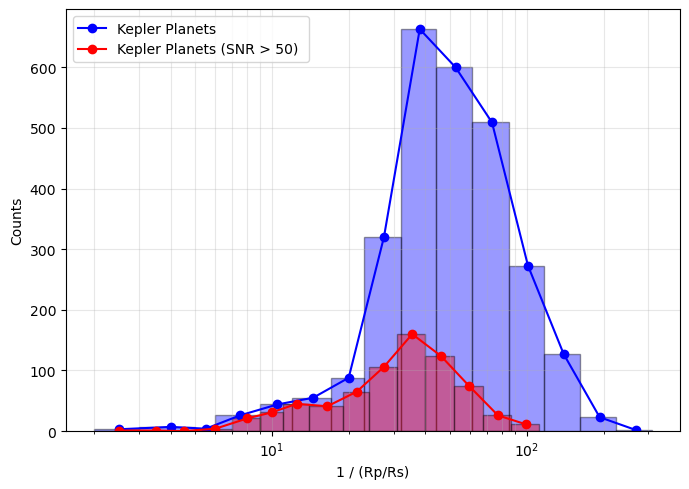

inverse_bins [[ 31  40]
 [ 40  52]
 [ 24  31]
 [ 52  67]
 [ 19  24]
 [ 11  14]
 [ 14  19]
 [  9  11]
 [ 67  87]
 [  7   9]
 [ 87 112]
 [  5   7]
 [  3   4]
 [  2   3]
 [  4   5]]
counts [160 124 106  74  65  45  41  31  26  21  11   4   1   1   0]


In [15]:
main(snr_cut = 50, n_rsrp_bins=15)

In [ ]:
import shape_utils,gen_ldc_ratio_grid,genlc_with_grid

class MegaPartIIPlots(SHAPE_SIZE=38):
    def __init__(self):
        self.SHAPE_SIZE = SHAPE_SIZE
        self.mlprep = MLPreProcessing(rsrp1=self.rsrp1, rsrp2=self.rsrp2, N=self.N)
        pass

    def compare_circle_lcs(rsrp = 30, LDCs=[0.3,0.5]):
        shape_circle = shape_utils.generate_circles(num_maps=1, 
                                                    size=self.SHAPE_SIZE)
        
        gen_ldc_ratio_grid.main(rsrp1=self.rsrp1,rsrp2=self.rsrp2,
                                koi_table_folder=self.koi_table_folder,
                                koi_table_filename=self.koi_table_filename,
                                outfile=self.ldc_ratio_grid_file,
                                fig_dir=self.figure_dir)
        
        

In [1]:
import numpy as np
from scipy.stats import gaussian_kde

def kde_sampling(
    data,
    n_samples=7745,
    low_cut=90,
    hig_cut=98,
    percentile_flag=True,
    random_seed=None
):

    rng = np.random.default_rng(random_seed)

    if percentile_flag is False:
        low = low_cut
        high = hig_cut
    else:
        low = np.percentile(data, low_cut)
        high = np.percentile(data, hig_cut)

    data_cut = data[(data >= low) & (data <= high)]

    if data_cut.size < 2:
        return rng.uniform(low, high, size=n_samples)

    kde = gaussian_kde(data_cut, bw_method=0.05)

    samples = np.array([])

    while samples.size < n_samples:
        new = kde.resample(n_samples, seed=rng)[0]
        new = new[(new >= low) & (new <= high)]
        samples = np.concatenate((samples, new))

    return samples[:n_samples]

data = np.linspace(0.01,0.5,700)
samples1 = kde_sampling(data, random_seed=42)
samples2 = kde_sampling(data, random_seed=42)

np.allclose(samples1, samples2)
# True

True

In [14]:
# samples2 = kde_sampling(data, random_state=42)
# np.allclose(samples1, samples2)

rng = np.random.default_rng(42)
print(rng.integers(0, 10, 5))

rng = np.random.default_rng(42)
print(rng.uniform(0.1, 2, 5))

param_sets [[[0.5534556451612903, 0.08402734659273728, 2.0]], 
    [[0.6802153225806452, 0.0025266574324012787, 3.0]],
    [[0.5273580645161291, 0.23824102944154388, 3.0]]]

processed_lightcurves[0,0:10] [1.         1.         1.         1.         1.         1.
 1.         0.9999755  0.9993214  0.99763477]


snr[0:10] [414.96907675 433.46773383 319.16178407 489.37963846 194.73342316
 358.7693373  126.01042843 322.23104266 260.94299322 206.38631896]
noise_multigauss[0,0:10] [ 1.47944590e-04 -1.21914824e-04  1.86074692e-04 -4.17045821e-04
  5.38479661e-04 -6.60354566e-05  1.99534912e-04  2.56771234e-04
  8.44105762e-05  6.45722762e-05]


processed_lightcurves[0,0:10] [1.         1.         1.         1.         1.         0.9999848
 0.9996733  0.99851096 0.996871   0.9948607 ]

[0 7 6 4 4]
[1.57051649 0.93386904 1.73133605 1.42499926 0.27893696]


[1.57051649 0.93386904 1.73133605 1.42499926 0.27893696]


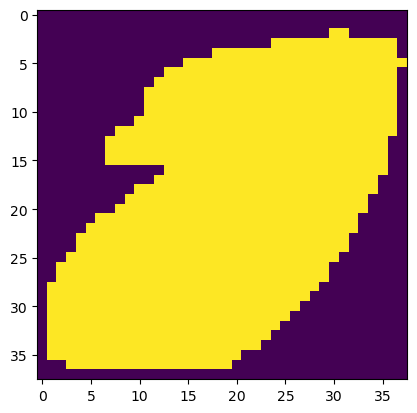

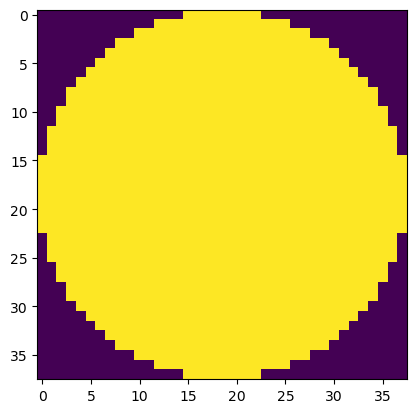

In [26]:
rng = np.random.default_rng(42)
print(rng.uniform(0.1, 2, 5))
import matplotlib.pyplot as plt
folder = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Mega_PartII/Test/Data/OM_Demo/"

f1 = np.load(f"{folder}99.npy")
f2 = np.load(f"{folder}99.npy")
plt.imshow(f1[0])
plt.show()

plt.imshow(f2[1])
plt.show()

In [16]:

#def plot_kepler_snr(koi_table='',kepler_lcs_fi):



df_new = pd.read_csv("../../Kepler/koi_confirmed_snr50_all_binned_koitable.csv")
kepler_lcs = np.load("../../Kepler/kepler_folded_lcs_snr50_all_binned.npy")
kepler_lcs_error = np.load("../../Kepler/kepler_folded_lcs_snr50_all_binned_err.npy")
#kepler_lcs_smooth = np.load("../../Kepler/kepler_folded_lcs_snr50_all_binned_smooth.npy")
kepler_lcs_depth = df_new["koi_depth"]/10**6
# kepler_lcs_rprs = df_new["koi_ror"]
# kepler_lcs_snr = df_new["koi_model_snr"]
# kepler_lcs_ldca = df_new["koi_ldm_coeff1"]
# kepler_lcs_ldcb = df_new["koi_ldm_coeff2"]

LDC_coeffs = np.zeros((len(kepler_lcs_ldca),3))
LDC_coeffs[:,0] = kepler_lcs_ldca.to_numpy()
LDC_coeffs[:,1] = kepler_lcs_ldcb.to_numpy()
LDC_coeffs[:,2] = kepler_lcs_rprs.to_numpy()

#np.save("Kepler/kepler_folded_lcs_snr50_all_binned_parameters_info.npy",parameters_sel)
#np.save("Kepler/kepler_folded_lcs_snr50_all_binned_times.npy",newkepler_lcs_times_sel)
np.save("../../Kepler/kepler_ldc_coeffs.npy",LDC_coeffs)

median_error = np.sqrt(np.median(kepler_lcs_error**2,axis=1))
mean_error = np.sqrt(np.mean(kepler_lcs_error**2,axis=1))
mean_error_tr = np.sqrt(np.sum(kepler_lcs_error**2,axis=1))/(kepler_lcs_error.shape[1])
print(median_error.shape)
print('mean_error.shape',mean_error.shape)
#kepler_lcs_snr_est = kepler_lcs_depth/median_error
kepler_lcs_snr_est = kepler_lcs_depth/mean_error_tr

mask = np.where(kepler_lcs_snr_est>10000)[0]
print('d',kepler_lcs_depth[mask])
print('e',mean_error[mask])

bins = 70
ncols = 3
nrows = 1
density = True
fontsize = 24
# check distribution of median error
fig, ax = plt.subplots(2,ncols,figsize=(12 * ncols, 18.5 * nrows))
ax[0,0].tick_params(axis='both', labelsize=fontsize-4, length=12, width=2)
ax[0,0].minorticks_on()
ax[0,0].tick_params(which='minor', length=8, width=1)

ax[0,1].tick_params(axis='both', labelsize=fontsize-4)
ax[0,2].tick_params(axis='both', labelsize=fontsize-4)
#ax[0,3].tick_params(axis='both', labelsize=fontsize-4)

ax[1,0].tick_params(axis='both', labelsize=fontsize-4)
ax[1,1].tick_params(axis='both', labelsize=fontsize-4)
ax[1,2].tick_params(axis='both', labelsize=fontsize-4)
#ax[1,3].tick_params(axis='both', labelsize=fontsize-4)


ax[0,0].hist(mean_error, bins=bins, density=density, alpha=0.5, color="red", edgecolor="black",label="mean")
ax[0,0].hist(median_error, bins=bins, density=density, alpha=0.5, color="steelblue", edgecolor="black", label=f'median')
ax[0,0].legend(fontsize=fontsize)
ax[0,0].set_title(f"Error Before V-scaling",fontsize=fontsize)
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel(r'median error',fontsize=fontsize)
ax[0,0].set_ylabel(r'Counts',fontsize=fontsize)

ax[0,1].hist(kepler_lcs_depth, bins=bins, density=density, alpha=0.6, color="steelblue", edgecolor="black",label="Kepler")
ax[0,1].set_title(f"Depth",fontsize=fontsize)
ax[0,1].set_yscale('log')
ax[0,1].set_xlabel(r'Depth',fontsize=fontsize)
ax[0,1].legend(fontsize=fontsize)


ax[0,2].hist(kepler_lcs_snr, bins=bins, density=density, alpha=0.6, color="red", edgecolor="black", 
             label=f"{len(kepler_lcs_depth)} koi snr")
ax[0,2].hist(kepler_lcs_depth*np.sqrt(120)/median_error, bins=350, density=density, alpha=0.6, color="steelblue", edgecolor="black",
             label=f"{len(kepler_lcs_depth)} estimated snr")
#ax[0,2].hist(kepler_lcs_depth/mean_error, bins=bins, density=density, alpha=0.6, color="steelblue", edgecolor="black")
#ax[0,2].hist(kepler_lcs_snr, bins=bins, density=density, alpha=0.6, color="red", edgecolor="black")
ax[0,2].set_title(f"SNR",fontsize=fontsize)
ax[0,2].set_yscale('log')
ax[0,2].set_xscale('log')
ax[0,2].set_xlabel(r'SNR = Depth/median error',fontsize=fontsize)
ax[0,2].legend(fontsize=fontsize)

# ax[1,0].hist(mean_error/kepler_lcs_depth, bins=bins, density=density, alpha=0.6, color="red", edgecolor="black", 
#              label=f'min = {np.min(mean_error/kepler_lcs_depth):0.8f}'+'\n'+f'max = {np.max(mean_error/kepler_lcs_depth):0.8f}')
ax[1,0].hist(median_error/kepler_lcs_depth, bins=bins, density=density, alpha=0.6, color="red", edgecolor="black", 
             label='')
ax[1,0].legend()
ax[1,0].set_title(f"Error after V-scaling",fontsize=fontsize)
ax[1,0].set_ylabel(r'Counts',fontsize=fontsize)

ax[1,1].hist(kepler_lcs_depth/kepler_lcs_depth, bins=bins, density=density, alpha=0.6, color="steelblue", edgecolor="black")

ax[1,2].hist(1/(median_error/kepler_lcs_depth), bins=bins, density=density, alpha=0.6, color="steelblue", edgecolor="black",
            label=f"{len(kepler_lcs_depth)} estimated snr=1/(scaled error)")
ax[1,2].set_yscale('log')


ax[1,0].set_xlabel(r'median error',fontsize=fontsize)
ax[1,1].set_xlabel(r'Depth',fontsize=fontsize)
ax[1,2].set_xlabel(r'SNR = 1/(median error/Depth)',fontsize=fontsize)

plt.savefig(
    '../figures/hist_snr_train_kep.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.2
)

plt.show()

print(kepler_lcs_snr.shape,median_error.shape)


fontsize = 8
fig, axes = scatter_with_half_slanted_bg(
    nrows=2,
    ncols=2,
    figsize=(10, 10),
    line_width=0.5,
    split=0,
    xlim=(mean_error.min()-mean_error.min()*0.25,mean_error.max()+mean_error.max()*0.25),
    ylim=(kepler_lcs_snr.to_numpy().min()-kepler_lcs_snr.to_numpy().min()*0.1,kepler_lcs_snr.to_numpy().max()+kepler_lcs_snr.to_numpy().max()*0.1),
)

# add_scatter(axes[0, 0], mean_error*10**5, kepler_lcs_snr, color="crimson", size=10,label='koi_model_snr')
# add_scatter(axes[0, 0], mean_error*10**5, kepler_lcs_snr_est, color="grey", size=10,label='SNR Estimated')
add_scatter(axes[0, 0], median_error*10**5, kepler_lcs_snr, color="crimson", size=10,label='koi_model_snr')
add_scatter(axes[0, 0], median_error*10**5, (kepler_lcs_depth*np.sqrt(kepler_lcs_error.shape[1])/median_error), 
            color="grey", size=10,label=r'SNR (Est) = depth/$( \sigma_{med}/ \sqrt{N_{tr}})$')

axes[0, 0].set_yscale('log')
axes[0, 0].axhline(50,ls='--',color='k')
axes[0, 0].set_xlim([(median_error.min()-median_error.min()*10.2)*10**5,(median_error.max()+median_error.max()*0.25)*10**5])
axes[0, 0].set_ylim([40,5*10**4])
axes[0, 0].set_xlabel(f"median error (x {10**-5})")
axes[0, 0].set_ylabel(f"SNR")
axes[0, 0].legend(fontsize=fontsize)


#add_scatter(axes[1, 0], mean_error*10**5, 100*np.abs(kepler_lcs_snr_est-kepler_lcs_snr)/kepler_lcs_snr, color="crimson", size=20,label='koi_depth')
add_scatter(axes[1, 0], mean_error_tr*10**5, 1*np.abs(kepler_lcs_snr_est)/kepler_lcs_snr, color="green", size=20,label='')
#axes[1, 0].axhline(1,ls='--',color='k')
axes[1, 0].axhline(np.percentile(np.abs(kepler_lcs_snr_est)/kepler_lcs_snr,90),ls='--',color='k',
                   label=f"90th percentile: {np.percentile(np.abs(kepler_lcs_snr_est)/kepler_lcs_snr,90):0.2f}")
#axes[1, 0].set_yscale('log')
axes[1, 0].set_xlim([-0.000002*10**5,0.00012*10**5])
axes[1, 0].set_ylim([-10,100])
axes[1, 0].set_xlabel(f"median error (x {10**-5})")
axes[1, 0].set_ylabel(f"SNR (est)/SNR KOI")
axes[1, 0].legend(fontsize=fontsize)



#add_scatter(axes[0, 0], median_error*10**5, kepler_lcs_snr, color="crimson", size=10,label='koi_model_snr')

# add_scatter(axes[0, 1], train_meta[:,0], train_meta[:,1], color="blue", size=10,
#             label=r'')
# add_scatter(axes[0, 1], a_neg, b_neg, color="k", size=10,
#             label=r'')


add_scatter(axes[0, 1], train_meta[:,0], train_meta[:,1], color="blue", size=10,
            label=r'')

add_scatter(axes[0, 1], kepler_lcs_ldca, kepler_lcs_ldcb, color="r", size=10,
            label=r'')

#axes[0, 1].set_yscale('log')
axes[0, 1].axhline(50,ls='--',color='k')
axes[0, 1].set_xlim([(kepler_lcs_ldca.min()-kepler_lcs_ldca.min()*0.25),(kepler_lcs_ldca.max()+kepler_lcs_ldca.max()*0.25)])
axes[0, 1].set_ylim([kepler_lcs_ldcb.min(),kepler_lcs_ldcb.max()])
axes[0, 1].set_xlabel(f"LDC Coeff1 (a)")
axes[0, 1].set_ylabel(f"LDC Coeff2 (b)")
axes[0, 1].legend(fontsize=fontsize)

rprs_test = 1.0/np.linspace(2,25,50)
depth_test = rprs_test**2

add_scatter(axes[1, 1], train_meta[:,2]**2, train_meta[:,2] , color="blue", size=5,label='')
add_scatter(axes[1, 1], kepler_lcs_depth, kepler_lcs_rprs, color="r", size=5,label='')
#add_scatter(axes[1, 1], depth_test,rprs_test, color="b", size=5,label='')
#add_scatter(axes[1, 1], train_depths, train_rp_rs , color="blue", size=5,label='')


axes[1, 1].set_xlim([(kepler_lcs_depth.min()-kepler_lcs_depth.min()*0.25),(kepler_lcs_depth.max()+kepler_lcs_depth.max()*0.25)])
axes[1, 1].set_ylim([kepler_lcs_rprs.min()-0.01,kepler_lcs_rprs.max()])
axes[1, 1].set_xlabel(f"KOI Depth")
axes[1, 1].set_ylabel(rf"KOI: $R_p/R_s$")
axes[1, 1].legend(fontsize=fontsize)

plt.savefig(
    '../figures/distribution_params_train_kep.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.2
)
plt.show()



SyntaxError: non-default argument follows default argument (3531894419.py, line 1)